# Scatter Matrix

This section showcases the scatter matrix. It contains examples of how to create scatter matrices using the [datachart.charts.ScatterMatrix](../../../references/charts/#datachart.charts.ScatterMatrix) function.

A scatter matrix draws a scatter chart for every pair of numeric variables, arranged in a square grid: the variable of each row on the y-axis, the variable of each column on the x-axis. The cells on the diagonal show each variable's own distribution. It is the quickest way to scan a table of measurements for relationships, clusters and outliers before choosing which pair to study in a [scatter chart](../scatterchart/).

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-scatter-matrix), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the scatter matrices are created using the `ScatterMatrix` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import ScatterMatrix

## Scatter Matrix Input Attributes

The `ScatterMatrix` function accepts keyword arguments for chart configuration. The main argument is `data`, the table of observations. It is either a list of records — one dictionary per observation — or one dictionary of columns, each a list of the same length. Numeric columns become the dimensions of the matrix; a categorical column can color the points with `hue`. Unlike the other charts, a scatter matrix draws one table: `data` is never a list of tables.

```python
ScatterMatrix(
    data=[{                                     # A list of records (or a dict of equal-length columns)
        "dim1": Union[int, float, None],        # Numeric column; None marks a missing value
        "dim2": Union[int, float, None],        # Numeric column
        "group": str,                           # Categorical column, for the hue
        # ... more columns
    }],
    dimensions=Optional[List[str]],             # The numeric columns to plot, in order
    hue=Optional[str],                          # The categorical column that colors the points
    diagonal=Optional[Union[DIAGONAL, str]],    # "hist" (default), "kde" or "none"
    lower_only=Optional[bool],                  # Leave the cells above the diagonal empty
    show_regression=Optional[bool],             # A least-squares line per hue group
    show_correlation=Optional[bool],            # The Pearson r above the diagonal
    sharex=Optional[bool],                      # Share x limits per column (default True)
    sharey=Optional[bool],                      # Share y limits per row (default True)
    title=Optional[str],                        # The figure title
    figsize=Optional[Tuple[float, float]],      # The figure size
    show_legend=Optional[bool],                 # The hue legend (default True with a hue)
    legend=Optional[LegendSettingAttrs],        # The legend title, columns and alignment
    show_grid=Optional[Union[SHOW_GRID, str]],  # The grid lines of every cell
    style=Optional[StyleAttrs],                 # Style attributes for every cell
)
```

For more details, see the [datachart.charts.ScatterMatrix](../../../references/charts/#datachart.charts.ScatterMatrix) function.

## Basics

The examples in this guide share one dataset: a sample of 30 penguins from the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0), ten of each species. Every penguin has four body measurements — bill length and depth (in mm), flipper length (in mm) and body mass (in g) — and three categorical attributes: its species, sex and the island it was observed on. The data is hard-coded in a hidden cell as `penguins`, a list of one dictionary per penguin.

In [2]:
PENGUIN_COLUMNS = ["bill length", "bill depth", "flipper length", "body mass", "species", "island", "sex"]

# ten penguins of each species, with the bill, flipper and body-mass measurements
PENGUIN_ROWS = [
    (39.1, 18.7, 181, 3750, "Adelie", "Torgersen", "male"),
    (39.5, 17.4, 186, 3800, "Adelie", "Torgersen", "female"),
    (40.3, 18.0, 195, 3250, "Adelie", "Torgersen", "female"),
    (36.7, 19.3, 193, 3450, "Adelie", "Torgersen", "female"),
    (39.3, 20.6, 190, 3650, "Adelie", "Torgersen", "male"),
    (37.8, 18.3, 174, 3400, "Adelie", "Biscoe", "female"),
    (37.7, 18.7, 180, 3600, "Adelie", "Biscoe", "male"),
    (35.9, 19.2, 189, 3800, "Adelie", "Biscoe", "female"),
    (39.5, 16.7, 178, 3250, "Adelie", "Dream", "female"),
    (37.2, 18.1, 178, 3900, "Adelie", "Dream", "male"),
    (46.5, 17.9, 192, 3500, "Chinstrap", "Dream", "female"),
    (50.0, 19.5, 196, 3900, "Chinstrap", "Dream", "male"),
    (51.3, 19.2, 193, 3650, "Chinstrap", "Dream", "male"),
    (45.4, 18.7, 188, 3525, "Chinstrap", "Dream", "female"),
    (52.7, 19.8, 197, 3725, "Chinstrap", "Dream", "male"),
    (45.2, 17.8, 198, 3950, "Chinstrap", "Dream", "female"),
    (46.1, 18.2, 178, 3250, "Chinstrap", "Dream", "female"),
    (51.3, 18.2, 197, 3750, "Chinstrap", "Dream", "male"),
    (46.0, 18.9, 195, 4150, "Chinstrap", "Dream", "female"),
    (51.3, 19.9, 198, 3700, "Chinstrap", "Dream", "male"),
    (46.1, 13.2, 211, 4500, "Gentoo", "Biscoe", "female"),
    (50.0, 16.3, 230, 5700, "Gentoo", "Biscoe", "male"),
    (48.7, 14.1, 210, 4450, "Gentoo", "Biscoe", "female"),
    (50.0, 15.2, 218, 5700, "Gentoo", "Biscoe", "male"),
    (47.6, 14.5, 215, 5400, "Gentoo", "Biscoe", "male"),
    (46.5, 13.5, 210, 4550, "Gentoo", "Biscoe", "female"),
    (45.4, 14.6, 211, 4800, "Gentoo", "Biscoe", "female"),
    (46.7, 15.3, 219, 5200, "Gentoo", "Biscoe", "male"),
    (43.3, 13.4, 209, 4400, "Gentoo", "Biscoe", "female"),
    (46.8, 15.4, 215, 5150, "Gentoo", "Biscoe", "male"),
]

penguins = [dict(zip(PENGUIN_COLUMNS, row)) for row in PENGUIN_ROWS]

In [3]:
penguins[:2]

[{'bill length': 39.1,
  'bill depth': 18.7,
  'flipper length': 181,
  'body mass': 3750,
  'species': 'Adelie',
  'island': 'Torgersen',
  'sex': 'male'},
 {'bill length': 39.5,
  'bill depth': 17.4,
  'flipper length': 186,
  'body mass': 3800,
  'species': 'Adelie',
  'island': 'Torgersen',
  'sex': 'female'}]

**Basic example.** Only the `data` argument is required. Every numeric column becomes a dimension, in the order the columns first appear, so the four measurements make a 4 × 4 matrix; the categorical columns are left out. Below the diagonal, each cell plots the variable of its row against the variable of its column; the diagonal shows a histogram of each variable, and the cells above it mirror the ones below.

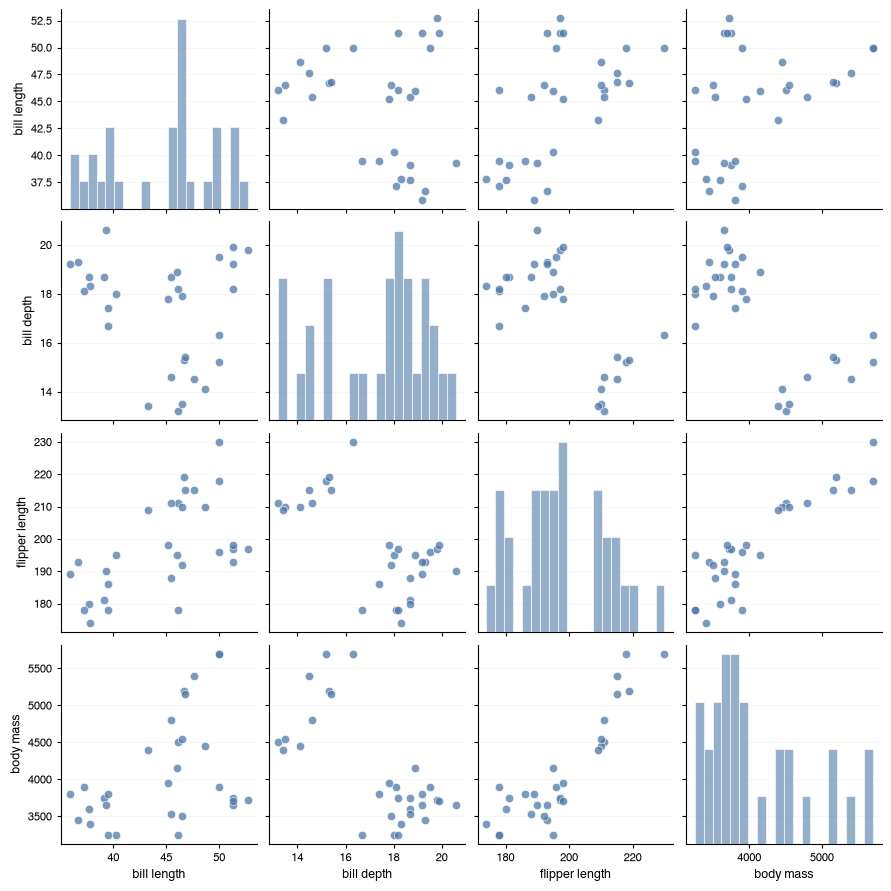

In [4]:
ScatterMatrix(data=penguins).show()

## Customizing the Scatter Matrix

Every customization is either a keyword argument of `ScatterMatrix` or an attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                      | Use                     | See |
| :---------------------------------------------- | :---------------------- | :-- |
| add a title or resize the figure                | `title`, `figsize`      | [Title and figure size](#title-and-figure-size) |
| choose and order the variables                  | `dimensions`            | [Selecting dimensions](#selecting-dimensions) |
| color the points by a category                  | `hue`                   | [Hue](#hue) |
| show a density curve or nothing on the diagonal | `diagonal`              | [Diagonal](#diagonal) |
| drop the mirrored cells                         | `lower_only`            | [Lower triangle only](#lower-triangle-only) |
| print the correlation of each pair              | `show_correlation`      | [Correlation](#correlation) |
| fit a line to each group                        | `show_regression`       | [Regression lines](#regression-lines) |
| give each cell its own axis range               | `sharex`, `sharey`      | [Shared axes](#shared-axes) |
| show grid lines                                 | `show_grid`             | [Grid lines](#grid-lines) |
| name or hide the legend                         | `legend`, `show_legend` | [Legend](#legend) |
| restyle points, bars, curves and lines          | `style`                 | [Style](#style) |

### Title and figure size

The `title` attribute adds a figure title. By default the figure gives every cell about two inches a side; `figsize` sets the whole figure's size in inches instead.

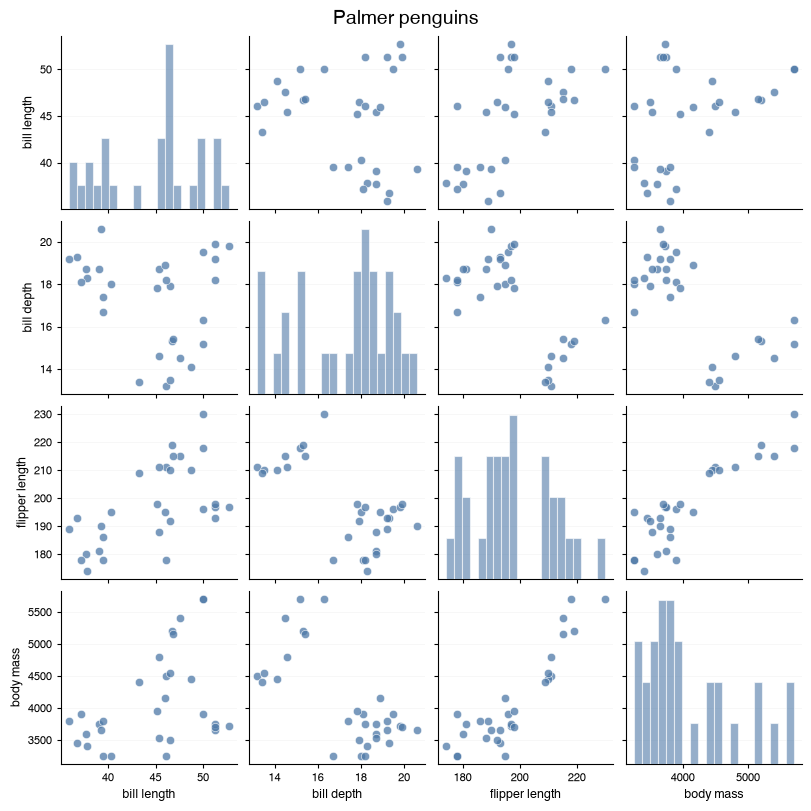

In [5]:
ScatterMatrix(
    data=penguins,
    # add the figure title and set its size
    title="Palmer penguins",
    figsize=(8, 8),
).show()

### Selecting dimensions

The `dimensions` attribute lists the numeric columns to plot, in order. The first dimension labels the top row and the left column. Missing values (`None`) are left out pair by pair, so an observation missing one measurement still appears in the cells that do not need it.

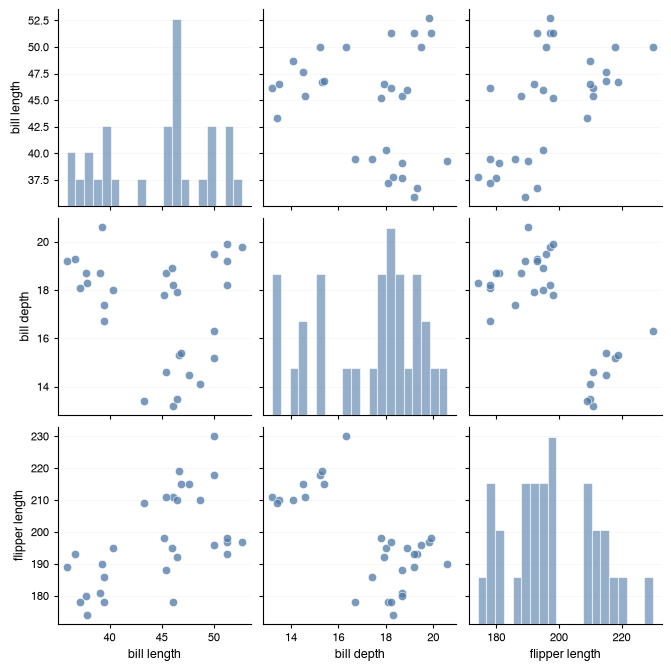

In [6]:
MEASUREMENTS = ["bill length", "bill depth", "flipper length"]

ScatterMatrix(
    data=penguins,
    # plot three measurements, in this order
    dimensions=MEASUREMENTS,
).show()

The same table can be passed as one dictionary of columns:

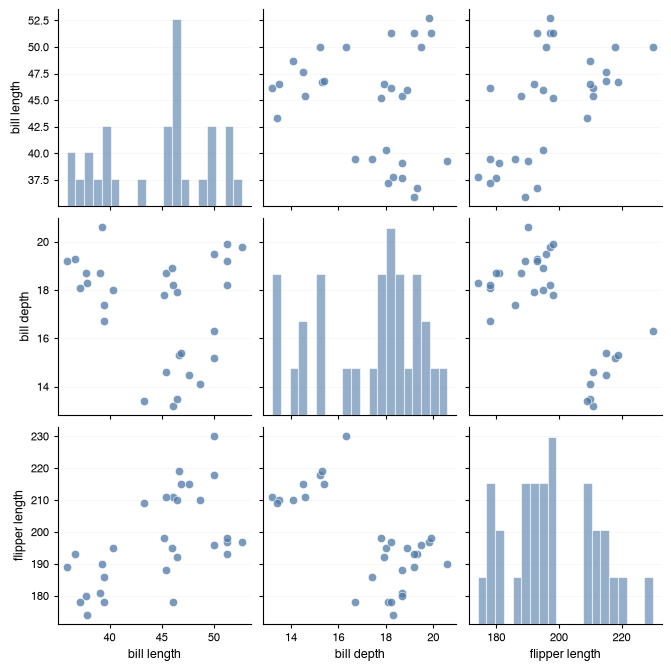

In [7]:
columns = {name: [penguin[name] for penguin in penguins] for name in MEASUREMENTS}

ScatterMatrix(data=columns).show()

### Hue

The `hue` attribute names a categorical column. Every category gets one color from the theme's palette — the same color in every cell — and one legend beside the matrix names them. The diagonal overlays one histogram per category. A numeric `hue` column raises an error: bin it into categories first.

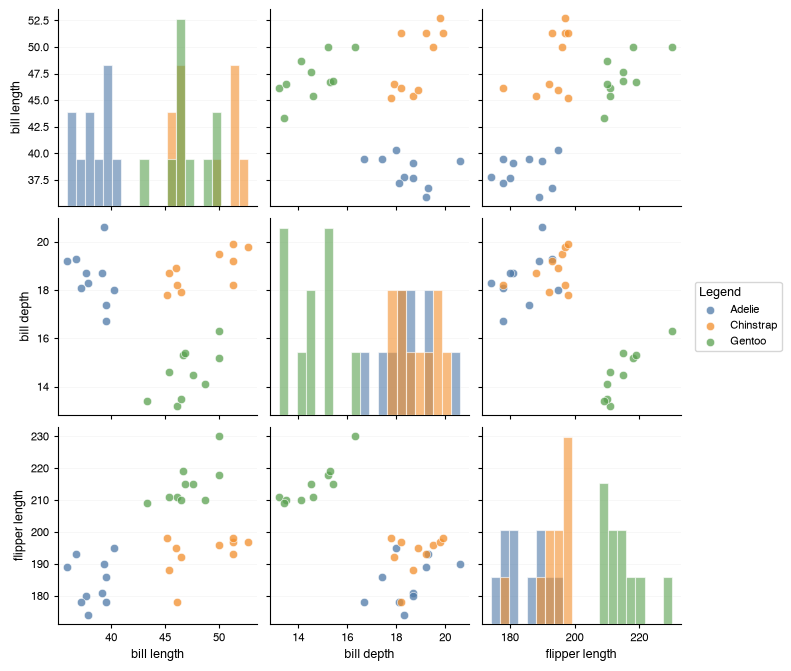

In [8]:
ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    # color the points by species
    hue="species",
).show()

### Diagonal

The `diagonal` attribute sets what each variable's own cell shows: a histogram (`DIAGONAL.HIST`, the default), a kernel density curve per hue group (`DIAGONAL.KDE`), or nothing (`DIAGONAL.NONE`). A diagonal cell's axis shows the scale of its row, like the other cells; the height of its histogram or curve is drawn to its own, unlabelled scale. See [datachart.constants.DIAGONAL](../../../references/constants/#datachart.constants.DIAGONAL).

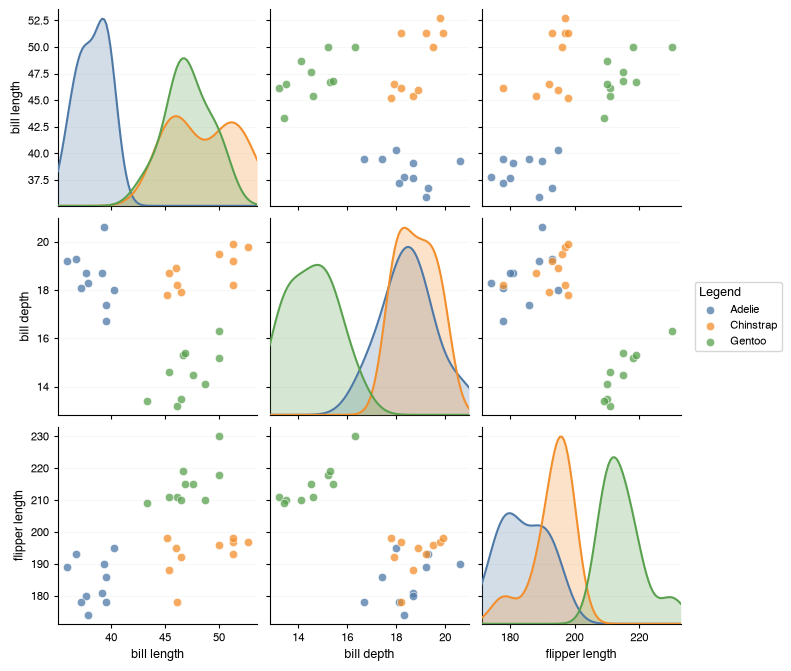

In [9]:
from datachart.constants import DIAGONAL

ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    hue="species",
    # a density curve per species on the diagonal
    diagonal=DIAGONAL.KDE,
).show()

With a blank diagonal, the tick labels and variable names move to the outermost cell that is drawn:

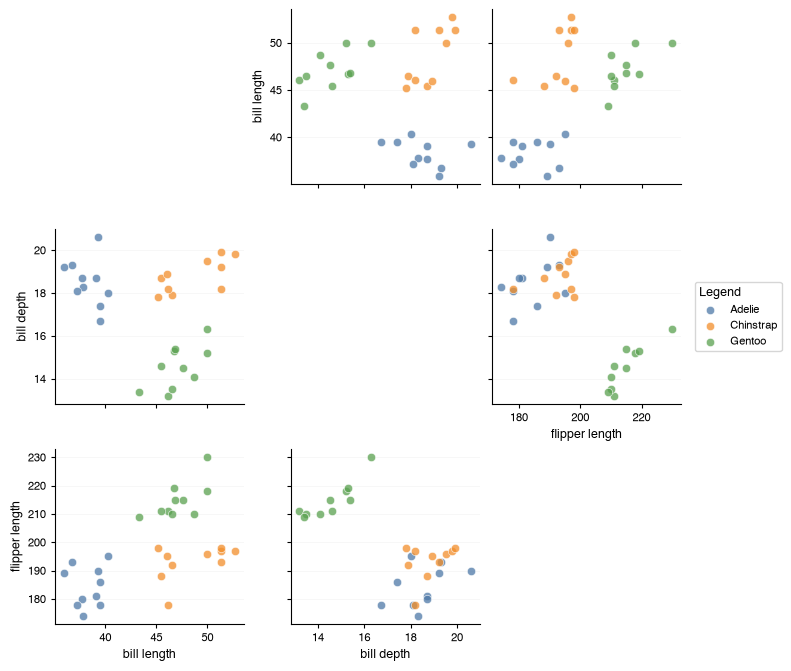

In [10]:
ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    hue="species",
    diagonal=DIAGONAL.NONE,
).show()

### Lower triangle only

The cells above the diagonal mirror the cells below it. Add `lower_only=True` to leave them empty. With a blank diagonal as well, the empty top row and right column are dropped.

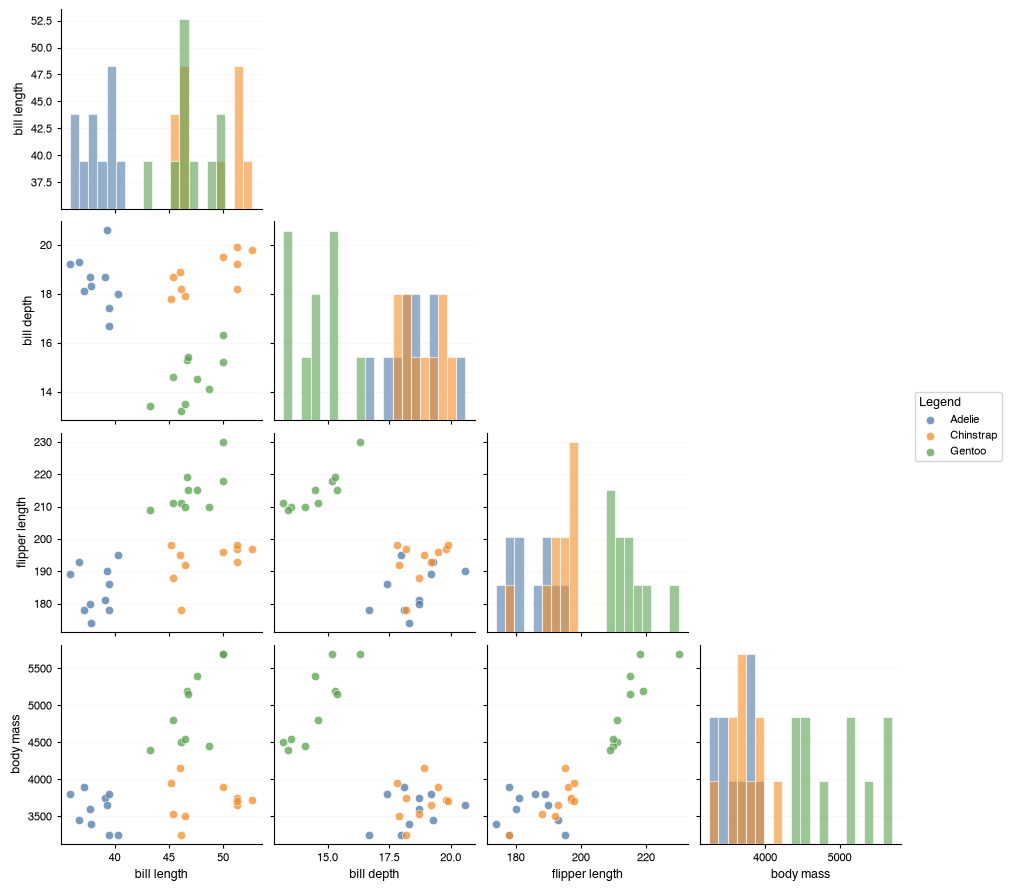

In [11]:
ScatterMatrix(
    data=penguins,
    hue="species",
    # draw only the cells below the diagonal
    lower_only=True,
).show()

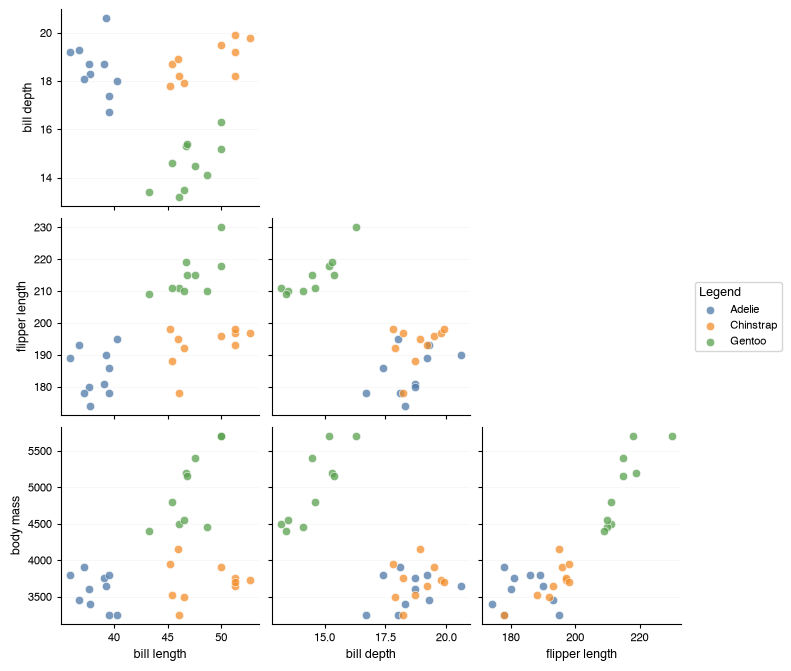

In [12]:
ScatterMatrix(
    data=penguins,
    hue="species",
    lower_only=True,
    diagonal=DIAGONAL.NONE,
).show()

### Correlation

Add `show_correlation=True` to replace the cells above the diagonal with the Pearson correlation coefficient of each pair — one line per hue group, in the group's color. `lower_only` wins: with both set, the cells stay empty. The same coefficient is available in code as [datachart.utils.stats.correlation](../../../references/utils/#datachart.utils.stats.correlation).

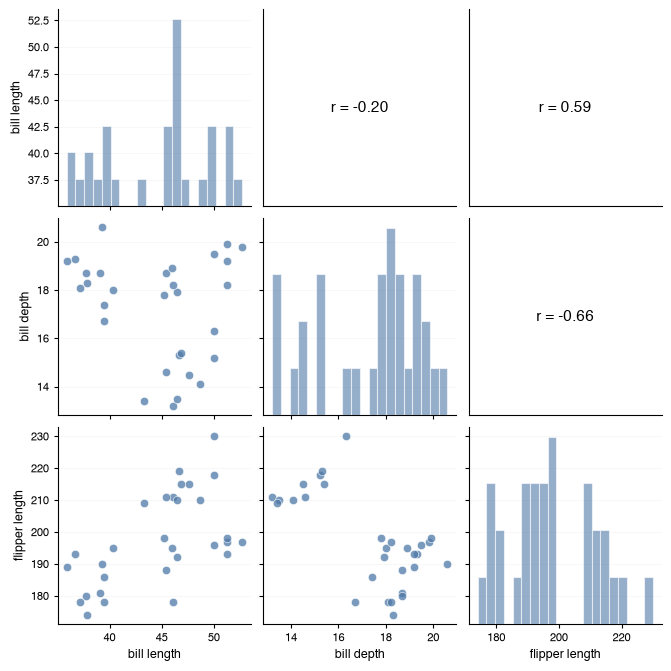

In [13]:
ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    # print the correlation above the diagonal
    show_correlation=True,
).show()

Split by species, the coefficients can differ from the pooled ones: a relationship within each species need not hold across all penguins, because the species differ in size.

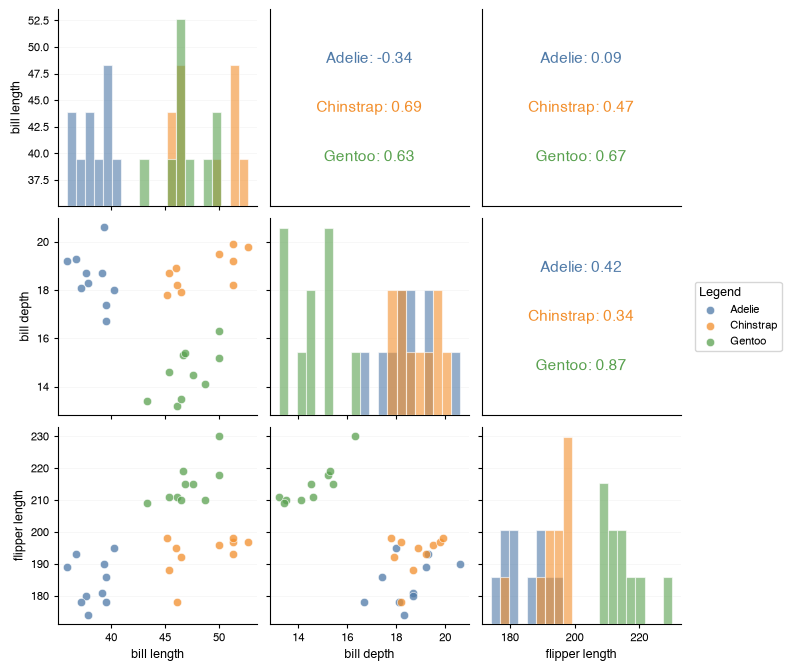

In [14]:
ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    hue="species",
    show_correlation=True,
).show()

### Regression lines

Add `show_regression=True` to fit a least-squares line to each hue group in every scatter cell. The line takes the group's color unless the style pins one.

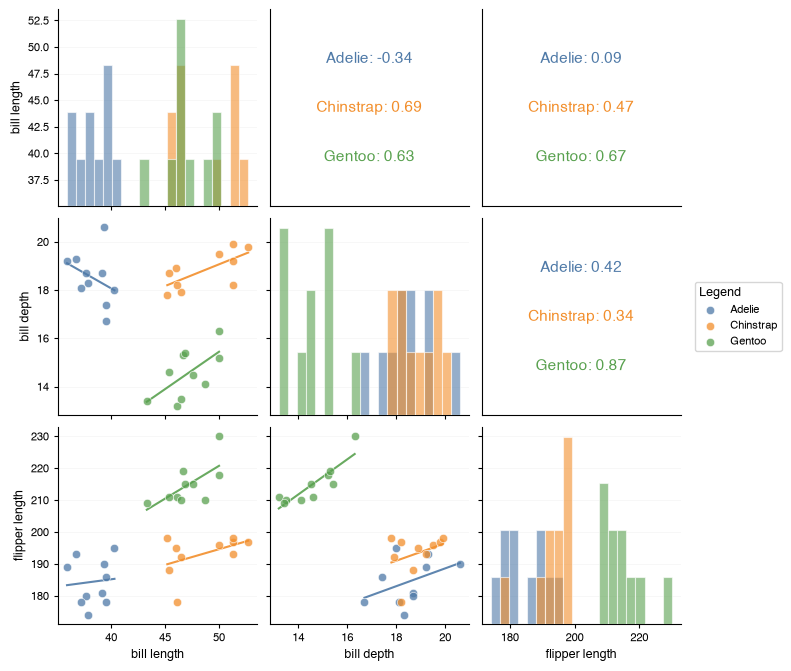

In [15]:
ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    hue="species",
    # fit a line to each species
    show_regression=True,
    show_correlation=True,
).show()

### Shared axes

By default the cells of a column share one x-axis and the cells of a row share one y-axis — the diagonal cells included — so only the bottom row and the left column label their ticks, and zooming one cell zooms its row and column. Set `sharex=False` or `sharey=False` to fit each cell to its own data; every cell then labels its own ticks, and the diagonal shows its counts or densities.

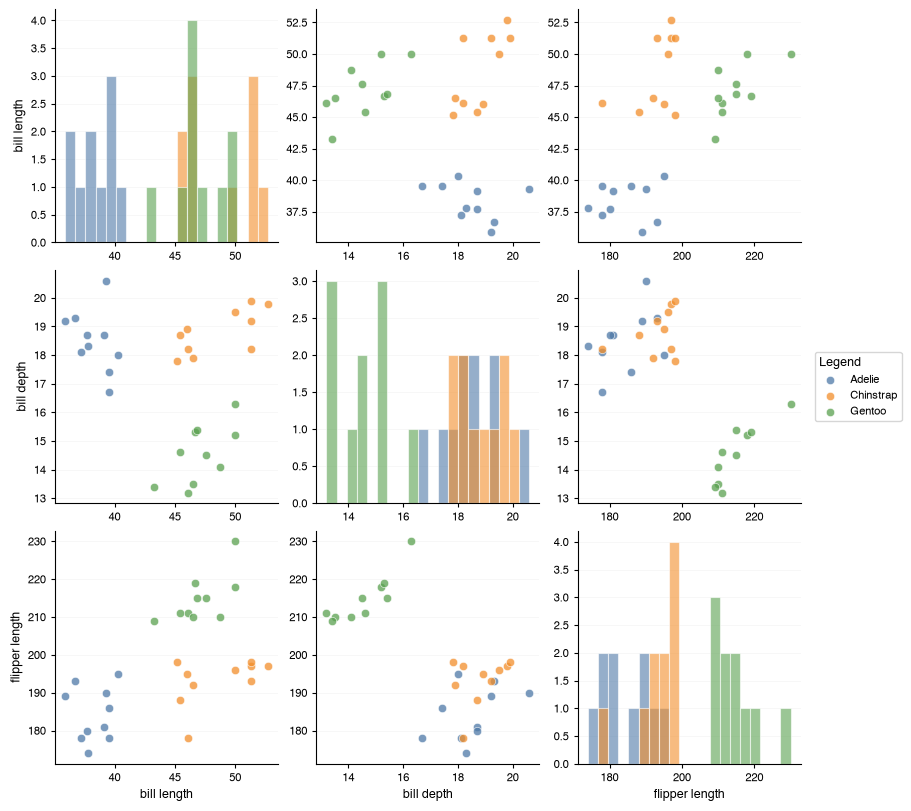

In [16]:
ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    hue="species",
    # fit every cell to its own data
    sharex=False,
    sharey=False,
    figsize=(9, 8),
).show()

### Grid lines

The `show_grid` attribute draws grid lines in every cell; see [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID). The cells with correlation text never show them.

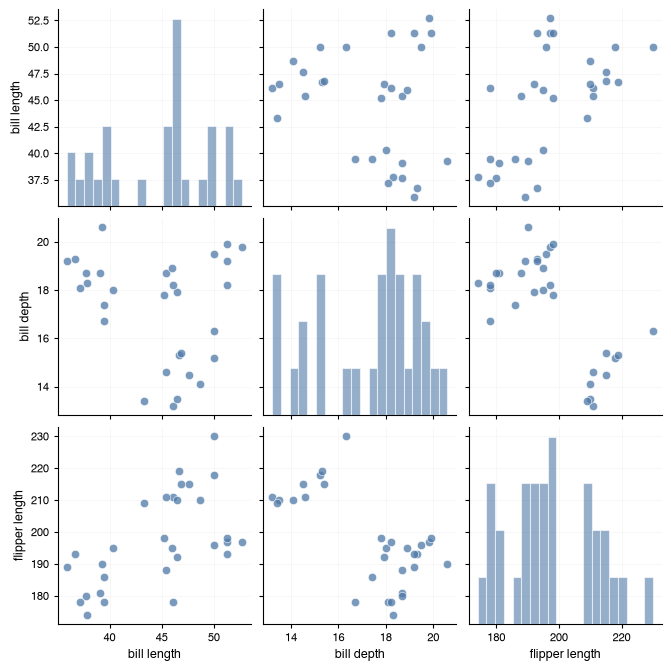

In [17]:
from datachart.constants import SHOW_GRID

ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    # draw grid lines on both axes
    show_grid=SHOW_GRID.BOTH,
).show()

### Legend

With a `hue`, one legend names the groups to the right of the matrix. The `legend` attribute sets its title, column count and alignment (see [datachart.typings.LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)); `show_legend=False` hides it.

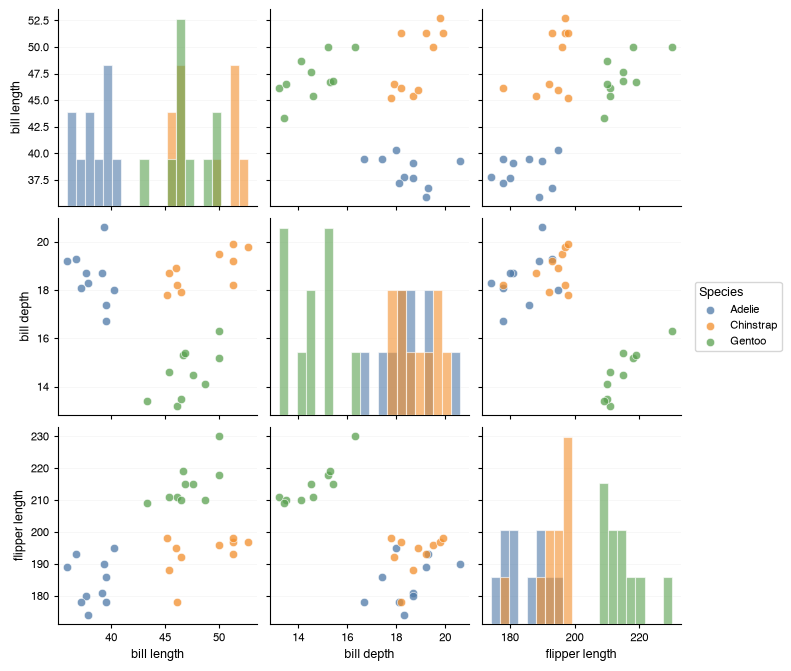

In [18]:
ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    hue="species",
    # name the legend
    legend={"title": "Species"},
).show()

### Style

The `style` attribute applies to every cell. The points take the `plot_scatter_*` attributes and the histograms the `plot_hist_*` attributes, as in the [scatter chart](../scatterchart/) and the [histogram](../histogram/). The `plot_scatter_matrix_*` attributes style what the matrix adds: the regression lines, the correlation text, the density curves and the transparency of the overlaid histograms. See [datachart.typings.ScatterMatrixStyleAttrs](../../../references/typings/#datachart.typings.ScatterMatrixStyleAttrs). The current values come from the [config](../../styling/themes/#what-a-theme-controls):

In [19]:
from datachart.config import config

{key: value for key, value in config.config.items() if key.startswith("plot_scatter_matrix_")}

{'plot_scatter_matrix_regression_color': None,
 'plot_scatter_matrix_regression_width': 1.5,
 'plot_scatter_matrix_regression_style': '-',
 'plot_scatter_matrix_correlation_size': 11,
 'plot_scatter_matrix_correlation_weight': 'normal',
 'plot_scatter_matrix_kde_width': 1.5,
 'plot_scatter_matrix_kde_alpha': 0.25,
 'plot_scatter_matrix_diagonal_alpha': 0.6}

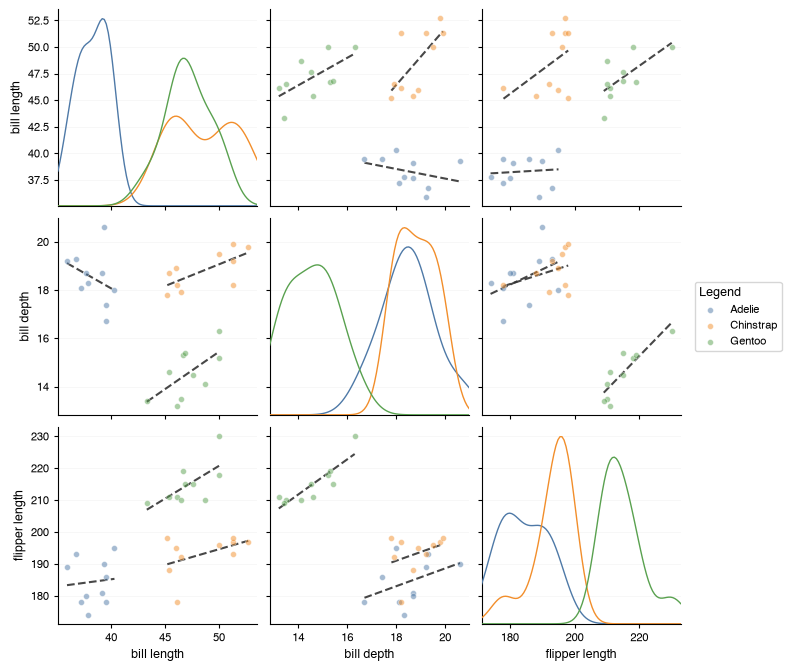

In [20]:
from datachart.constants import LINE_STYLE

ScatterMatrix(
    data=penguins,
    dimensions=MEASUREMENTS,
    hue="species",
    diagonal=DIAGONAL.KDE,
    show_regression=True,
    style={
        # smaller, more transparent points
        "plot_scatter_size": 18,
        "plot_scatter_alpha": 0.5,
        # dashed regression lines in one color
        "plot_scatter_matrix_regression_color": "#333333",
        "plot_scatter_matrix_regression_style": LINE_STYLE.DASHED,
        # thin density curves without a fill
        "plot_scatter_matrix_kde_width": 1.0,
        "plot_scatter_matrix_kde_alpha": 0,
    },
).show()

## Composing Scatter Matrices

A scatter matrix is a grid of charts, so [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) places it in one of its cells, beside any other chart; its title becomes the cell's heading. It has no single coordinate space, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) cannot overlay it.

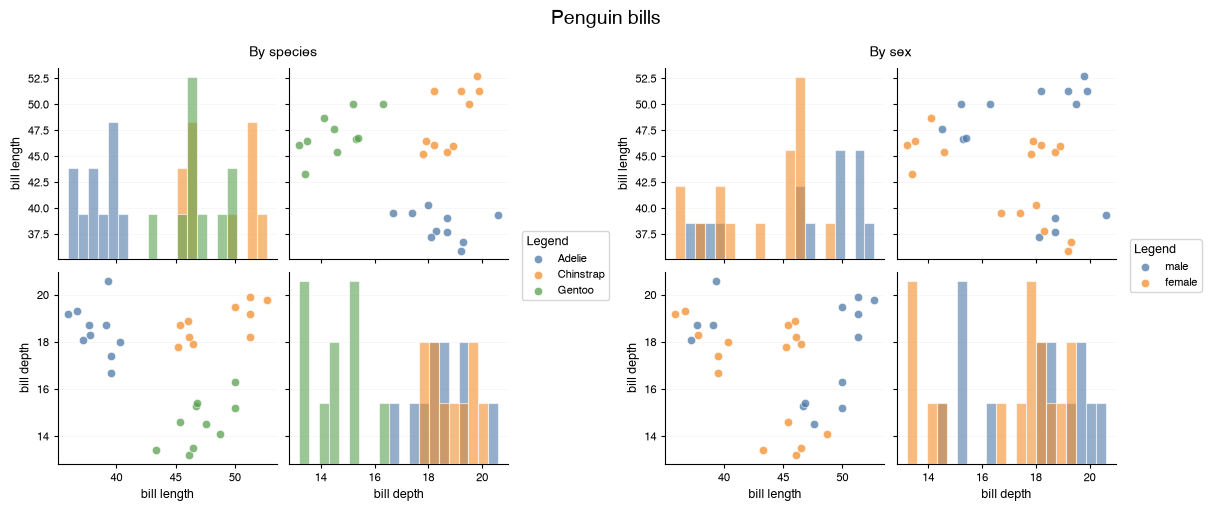

In [21]:
from datachart.utils import Grid

by_species = ScatterMatrix(
    data=penguins,
    dimensions=["bill length", "bill depth"],
    hue="species",
    title="By species",
)
by_sex = ScatterMatrix(
    data=penguins,
    dimensions=["bill length", "bill depth"],
    hue="sex",
    title="By sex",
)

Grid([[by_species, by_sex]], title="Penguin bills", figsize=(12, 5)).show()

### Themes

A theme sets the palette, the fonts and the marks of every cell at once. See the [Theme Gallery](../../styling/theme-gallery/) for every chart under each theme. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme).

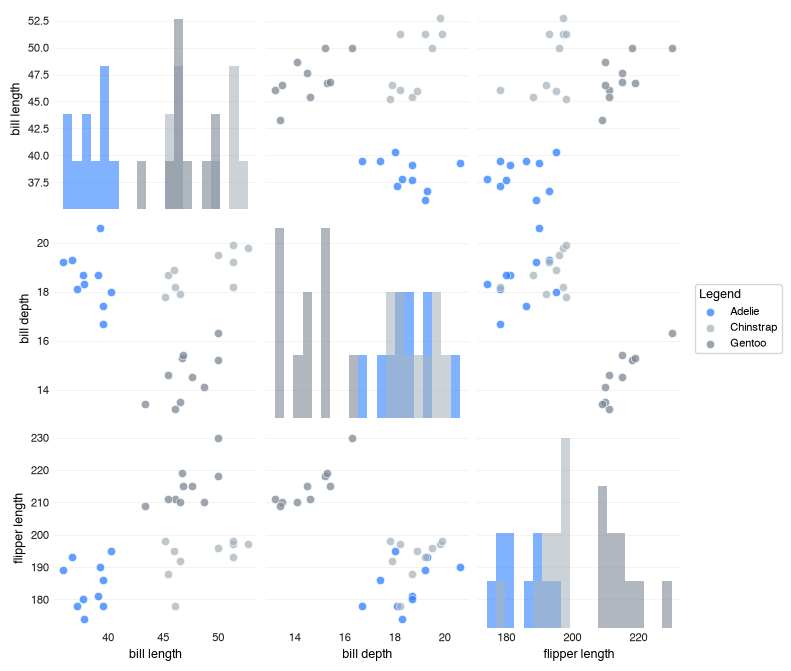

In [22]:
from datachart.constants import THEME

config.set_theme(THEME.MINIMAL)
figure = ScatterMatrix(data=penguins, dimensions=MEASUREMENTS, hue="species")
config.set_theme(THEME.DEFAULT)
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [23]:
from datachart.utils import save_figure

figure = ScatterMatrix(data=penguins, hue="species")
save_figure(figure, "./fig_scatter_matrix.png", dpi=300)

['./fig_scatter_matrix.png']

## Real-World Examples

### Example 1: Car specs

A dozen cars (illustrative figures) described by engine power, weight and fuel use. Within each engine type, power, weight and fuel use rise together; the electric cars sit apart on the fuel axis. The correlations above the diagonal and the density curves on it summarise each group.

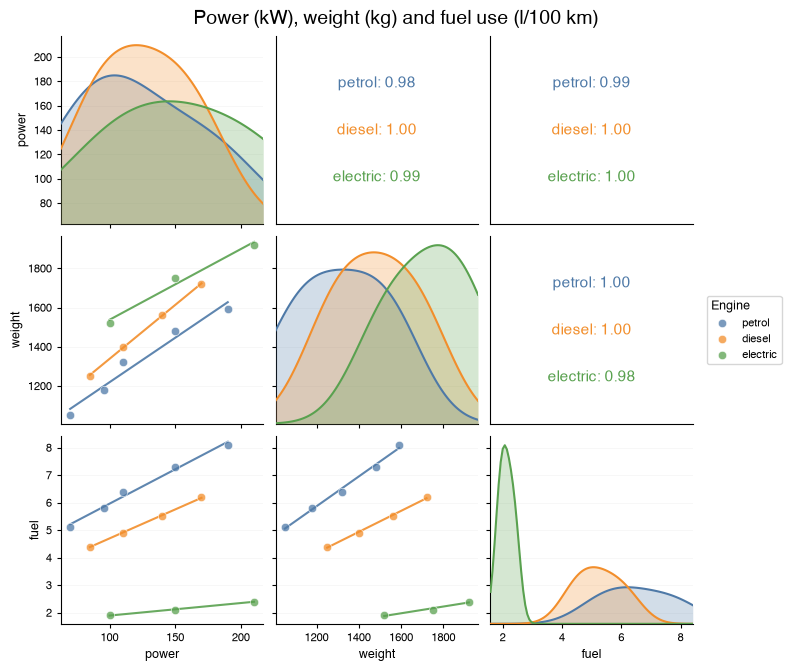

In [24]:
cars = [
    {"power": 70, "weight": 1050, "fuel": 5.1, "engine": "petrol"},
    {"power": 96, "weight": 1180, "fuel": 5.8, "engine": "petrol"},
    {"power": 110, "weight": 1320, "fuel": 6.4, "engine": "petrol"},
    {"power": 150, "weight": 1480, "fuel": 7.3, "engine": "petrol"},
    {"power": 190, "weight": 1590, "fuel": 8.1, "engine": "petrol"},
    {"power": 85, "weight": 1250, "fuel": 4.4, "engine": "diesel"},
    {"power": 110, "weight": 1400, "fuel": 4.9, "engine": "diesel"},
    {"power": 140, "weight": 1560, "fuel": 5.5, "engine": "diesel"},
    {"power": 170, "weight": 1720, "fuel": 6.2, "engine": "diesel"},
    {"power": 100, "weight": 1520, "fuel": 1.9, "engine": "electric"},
    {"power": 150, "weight": 1750, "fuel": 2.1, "engine": "electric"},
    {"power": 210, "weight": 1920, "fuel": 2.4, "engine": "electric"},
]

ScatterMatrix(
    data=cars,
    hue="engine",
    diagonal=DIAGONAL.KDE,
    show_correlation=True,
    show_regression=True,
    legend={"title": "Engine"},
    title="Power (kW), weight (kg) and fuel use (l/100 km)",
).show()

### Example 2: Model evaluation metrics

The scores of ten runs of a classifier (illustrative). Before reporting one metric, check which ones move together: precision and recall trade off, F1 barely moves, and latency is unrelated to precision and recall. Only the lower triangle is drawn, with no diagonal.

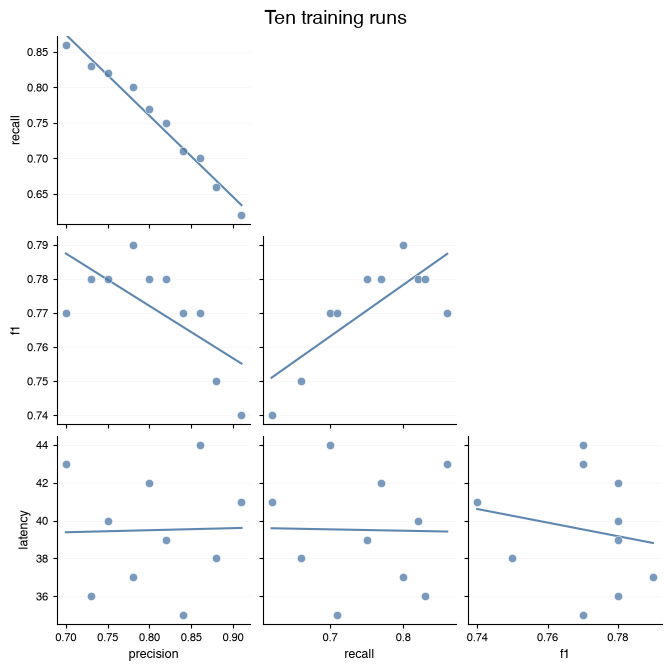

In [25]:
runs = {
    "precision": [0.91, 0.88, 0.86, 0.84, 0.82, 0.80, 0.78, 0.75, 0.73, 0.70],
    "recall": [0.62, 0.66, 0.70, 0.71, 0.75, 0.77, 0.80, 0.82, 0.83, 0.86],
    "f1": [0.74, 0.75, 0.77, 0.77, 0.78, 0.78, 0.79, 0.78, 0.78, 0.77],
    "latency": [41, 38, 44, 35, 39, 42, 37, 40, 36, 43],
}

ScatterMatrix(
    data=runs,
    lower_only=True,
    diagonal=DIAGONAL.NONE,
    show_regression=True,
    title="Ten training runs",
).show()